# Tokenizer

In [1]:
import re
from typing import List
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

## Corpus Preprocessing

### Normalization

In this step, we normalize text when needed (e.g., lowercase or removing special chars). For byte-level BPE we usually avoid aggressive normalization, so we keep the original bytes and only apply optional tweaks for experimentation.

In [2]:
def normalize_text(text: str, lowercase: bool = True, only_alphanumeric: bool = False) -> str:
    """
    Normalize text with optional lowercase and character filtering.
    
    Args:
        text (str): The input text to normalize.
        lowercase (bool): If True, convert text to lowercase.
        only_alphanumeric (bool): If True, only keep alphanumeric characters.
        
    Returns:
        str: The normalized text.
    """
    if lowercase:
        text = text.lower()  # Convert to lowercase
    if only_alphanumeric:
        text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove special characters
    return text


### Pre-tokenization

In this step, we split the text into tokens while **preserving leading spaces**. This mirrors modern byte-level tokenizers, where the space before a word matters (e.g., "hello" vs " hello"). We also keep special tokens intact.

In [3]:
def pre_tokenize(text: str, special_tokens: list[str]) -> list[str]:
    """
    Pre-tokenize text by splitting on special tokens and keeping leading spaces.
    
    Args:
        text (str): The input text to pre-tokenize.
        special_tokens (list[str]): A list of special tokens to keep intact.
    
    Returns:
        list[str]: A list of pre-tokens.
    """
    # Split the text by special tokens, keeping them as separate pieces
    pattern = r'(' + '|'.join(map(re.escape, special_tokens)) + r')'
    parts = re.split(pattern, text)

    tokens = []
    for part in parts:
        if not part:
            continue
        if part in special_tokens:
            tokens.append(part)
        else:
            # Keep leading spaces attached to the following word
            tokens.extend(re.findall(r'\s+\S+|\S+', part))

    return tokens


### Dict of word counts

In this step, we will create a dictionary of word counts, which will be used to build the vocabulary and assign unique IDs to each token.
The goal is build something like this:

```
{
    "the": 0,
    "cat": 1,
    "sat": 2,
    "on": 3,
    "mat": 4,
    ...
}
```

In [4]:
def create_word_count_dict(text_words: List[str]) -> dict:
    """
    Create a dictionary of word counts from a list of words.
    
    Args:
        text_words (List[str]): A list of words to count.
    Returns:
        dict: A dictionary where keys are words and values are their counts.
    """
    word_count_dict = dict(Counter(text_words))
    return word_count_dict


### Base split

In this step, each token is split into **bytes**. Special tokens remain intact as a single token. For example:
```
" hola" -> [b" ", b"h", b"o", b"l", b"a"]
"<user>" -> ["<user>"]
```

In [5]:
def base_split(words_dict: dict[str, int], special_tokens: list[str]) -> dict[tuple[bytes | str, ...], int]:
    """
    Perform a base split of tokens into bytes while keeping special tokens intact.
    
    Args:
        words_dict (dict[str, int]): A dictionary of tokens and their counts.
        special_tokens (list[str]): A list of special tokens to keep intact.
        
    Returns:
        dict[tuple[bytes | str, ...], int]: A dictionary where keys are tuples of tokens and values are their counts.
    """
    special_tokens_set = set(special_tokens)
    split_dict = {}
    for token, count in words_dict.items():
        if token in special_tokens_set:
            split_dict[(token,)] = count
            continue
        byte_tokens = tuple(bytes([b]) for b in token.encode("utf-8"))
        split_dict[byte_tokens] = count
    return split_dict


## Training loop (Merging)

In [ ]:
STEPS: int = 1_000_000
MIN_COUNT: int = 5
MAX_VOCAB_SIZE: int = 256*1024

### Count pairs

In this step we will loop through the dict of word counts and count which pairs of tokkens adjacent are the most common. Example:
From this dict
```
{"h o l a </w>": 5, "m u n d o </w>": 3, "h o l a s </w>": 2}
```
result is:
```
("h", "o"): 7
```

In [7]:
def get_most_common_token_pair(
    word_count_dict: dict[tuple[bytes | str, ...], int],
    special_tokens: set[str],
) -> tuple[tuple[bytes | str, bytes | str] | None, int]:
    """
    Get the most common adjacent token pair from a dictionary of word counts.
    
    Args:
        word_count_dict (dict[tuple[bytes | str, ...], int]): Tokenized words as tuples and their counts.
        special_tokens (set[str]): Special tokens to exclude from merging.
        
    Returns:
        tuple[tuple[bytes | str, bytes | str] | None, int]: The most common adjacent token pair and its frequency.
    """
    def is_special(token: bytes | str) -> bool:
        return isinstance(token, str) and token in special_tokens

    pairs = Counter()
    for tokens, count in word_count_dict.items():
        for i in range(len(tokens) - 1):
            first, second = tokens[i], tokens[i + 1]
            if is_special(first) or is_special(second):
                continue
            pairs[(first, second)] += count

    if not pairs:
        return None, 0

    most_common_pair, frequency = pairs.most_common(1)[0]
    return most_common_pair, frequency


### Update dict of word counts

In this step, we will update the dict of word counts by merging the most common pair of tokens. For example, if the most common pair is ("h", "o"), we will merge it into a new token "ho" and update the dict of word counts accordingly. The updated dict would look like this:
```
{"ho l a </w>": 5, "m u n d o </w>": 3, "ho l a s </w>": 2}
```

> Note: We now use tuples of **byte tokens** (and keep special tokens as strings). This is efficient and matches byte-level BPE, where every character is represented by its raw bytes.

In [8]:
def merge_tokens(tokens: tuple, pair: tuple) -> tuple:
    """Helper to merge a specific pair in a single tuple of tokens."""
    new_tokens = []
    first, second = pair
    new_token = first + second
    i = 0
    while i < len(tokens):
        if i < len(tokens) - 1 and tokens[i] == first and tokens[i+1] == second:
            new_tokens.append(new_token)
            i += 2
        else:
            new_tokens.append(tokens[i])
            i += 1
    return tuple(new_tokens)


In [9]:
def get_pair_stats(word_count_dict: dict[tuple, int], special_tokens: set[str]) -> dict[tuple, int]:
    """Get frequency of all adjacent pairs."""
    stats = Counter()
    for tokens, count in word_count_dict.items():
        for i in range(len(tokens) - 1):
            pair = (tokens[i], tokens[i+1])
            if any(isinstance(t, str) and t in special_tokens for t in pair):
                continue
            stats[pair] += count
    return stats

def get_inverted_index(word_count_dict: dict[tuple, int]) -> dict[tuple, set]:
    """Map each pair to the set of words (tuples) it appears in."""
    index = {}
    for tokens in word_count_dict:
        for i in range(len(tokens) - 1):
            pair = (tokens[i], tokens[i+1])
            if pair not in index:
                index[pair] = set()
            index[pair].add(tokens)
    return index


In [10]:
def token_to_str(token: bytes | str) -> str:
    """Readable display for byte tokens in progress logs."""
    if isinstance(token, bytes):
        try:
            return token.decode("utf-8")
        except UnicodeDecodeError:
            return f"0x{token.hex()}"
    return token


def pair_to_str(pair: tuple[bytes | str, bytes | str]) -> str:
    return "".join(token_to_str(t) for t in pair)


## Loop

In [11]:
data_path = Path("/home/abelsr/Documentos/llm-from-scratch/data/notebooks/claude_opus_4.6_4.7_reasoning_8.7k.csv")
df = pd.read_csv(data_path)
df

,category,model,processed
0,coding,claude-opus-4-6,<system>You are a computer science tutor. Expl...
1,coding,claude-opus-4-6,<system>You are a computer science tutor. Expl...
2,coding,claude-opus-4-6,<system>You are a DevOps engineer. Focus on re...
3,coding,claude-opus-4-7,<system>You are a senior React/TypeScript engi...
4,coding,claude-opus-4-7,<system>You are an event-driven systems engine...
...,...,...,...
38499,roleplay_villain,claude-opus-4-6,"<system>You are Iago, now speaking separately ..."
38500,roleplay_villain,claude-opus-4-6,<system>You are Cersei Lannister of House Lann...
38501,narrative_prose,claude-opus-4-6,<system>You are a literary fiction writer. Cha...
38502,roleplay_villain,claude-opus-4-6,<system>You are Erik Lehnsherr — Magneto — sea...


In [12]:
corpus = ' '.join(df["processed"].tolist())
print(f"Corpus length: {float(len(corpus)):,.2f} characters")

Corpus length: 249,924,225.00 characters


In [13]:
normalized_corpus = normalize_text(corpus, lowercase=False)
print(f"Normalized corpus length: {float(len(normalized_corpus)):,.2f} characters")


Normalized corpus length: 249,924,225.00 characters


In [14]:
SPECIAL_TOKENS = [
    "<user>",
    "</user>",
    "<assistant>",
    "</assistant>",
    "<system>",
    "</system>",
    "<think>",
    "</think>",
]
SPECIAL_TOKENS_SET = set(SPECIAL_TOKENS)

words = pre_tokenize(
    normalized_corpus,
    special_tokens=SPECIAL_TOKENS,
)
print(f"Number of words: {len(words):,}")


Number of words: 38,364,174


In [15]:
word_count_dict = create_word_count_dict(words)

In [16]:
print(f"Number of unique words: {len(word_count_dict):,}")
print(f"Most common word: '{max(word_count_dict, key=word_count_dict.get)}' with count {max(word_count_dict.values()):,}")

Number of unique words: 693,667
Most common word: ' the' with count 1,697,757


In [17]:
base_split_dict = base_split(word_count_dict, SPECIAL_TOKENS)
print(f"Number of unique tokens after base split: {len(base_split_dict):,}")


Number of unique tokens after base split: 693,667


In [18]:
# Efficiency & Metrics Setup
stats = get_pair_stats(base_split_dict, SPECIAL_TOKENS_SET)
inverted_index = get_inverted_index(base_split_dict)

# Metrics tracking
history = {
    "step": [],
    "compression_ratio": [],
    "max_freq": [],
    "vocab_size": []
}

initial_bytes = len(normalized_corpus.encode("utf-8"))

rule_set = []
pg = tqdm(total=STEPS, desc="Optimized BPE Training")

for step in range(STEPS):
    if not stats:
        break
        
    # 1. Get most common pair (Efficiently from stats)
    most_common_pair, frequency = stats.most_common(1)[0]
    
    # Early Stopping Logic
    if frequency < MIN_COUNT:
        print(f"Stopping: Frequency {frequency} < {MIN_COUNT}")
        break
    if len(rule_set) >= MAX_VOCAB_SIZE - 256 - len(SPECIAL_TOKENS):
        print("Stopping: Max vocab size reached")
        break
        
    # 2. Update split dict and inverted index (only for affected words)
    words_to_update = list(inverted_index.get(most_common_pair, []))
    first, second = most_common_pair
    new_token = first + second
    
    for old_tokens in words_to_update:
        count = base_split_dict.pop(old_tokens)
        new_tokens = merge_tokens(old_tokens, most_common_pair)
        
        # Update word count dict
        base_split_dict[new_tokens] = base_split_dict.get(new_tokens, 0) + count
        
        # Update pair stats: remove old pairs, add new ones
        # This is the complex part for a full inverted index update, 
        # but for this educational version, we'll re-scan just the affected word
        for i in range(len(old_tokens) - 1):
            p = (old_tokens[i], old_tokens[i+1])
            if any(isinstance(t, str) and t in SPECIAL_TOKENS_SET for t in p): continue
            stats[p] -= count
            if stats[p] <= 0: del stats[p]
            # Remove from inverted index too
            if old_tokens in inverted_index.get(p, set()):
                inverted_index[p].remove(old_tokens)

        for i in range(len(new_tokens) - 1):
            p = (new_tokens[i], new_tokens[i+1])
            if any(isinstance(t, str) and t in SPECIAL_TOKENS_SET for t in p): continue
            stats[p] += count
            if p not in inverted_index: inverted_index[p] = set()
            inverted_index[p].add(new_tokens)

    rule_set.append(most_common_pair)
    
    # 3. Metrics calculation (every 100 steps to avoid slowdown)
    if step % 100 == 0 or step == STEPS - 1:
        current_token_count = sum(len(t) * c for t, c in base_split_dict.items())
        compression_ratio = initial_bytes / current_token_count
        
        history["step"].append(step)
        history["compression_ratio"].append(compression_ratio)
        history["max_freq"].append(frequency)
        history["vocab_size"].append(256 + len(SPECIAL_TOKENS) + len(rule_set))
        
        pg.set_postfix({
            "CR": f"{compression_ratio:.2f}x",
            "Token": token_to_str(new_token),
            "Freq": frequency
        })

    pg.update(1)

pg.close()


Optimized BPE Training:   0%|          | 0/100000 [00:00<?, ?it/s]

In [ ]:
print(f"Final vocabulary size: {256 + len(SPECIAL_TOKENS) + len(rule_set):,} tokens")

Final vocabulary size: 100,264 tokens


## Creating the Final Tokenizer

Now that we have the `rule_set`, we can build the actual vocabulary. The vocabulary consists of the initial base tokens (all 256 possible bytes + special tokens) and all the merged tokens created during the BPE process.


In [20]:
def build_tokenizer(rule_set: list[tuple[bytes | str, bytes | str]], special_tokens: list[str]) -> tuple[dict[bytes | str, int], dict[int, bytes | str]]:
    """
    Build the mapping from tokens to IDs and vice-versa.
    """
    vocab = {}
    
    # 1. Add base bytes (0-255)
    for i in range(256):
        vocab[bytes([i])] = i
        
    # 2. Add special tokens
    curr_id = 256
    for st in special_tokens:
        vocab[st] = curr_id
        curr_id += 1
        
    # 3. Add merged tokens from the rules
    for pair in rule_set:
        new_token = pair[0] + pair[1]
        if new_token not in vocab:
            vocab[new_token] = curr_id
            curr_id += 1
            
    # Create the reverse mapping
    id_to_token = {v: k for k, v in vocab.items()}
    
    return vocab, id_to_token

vocab, id_to_token = build_tokenizer(rule_set, SPECIAL_TOKENS)
print(f"Final Vocab Size: {len(vocab):,}")


Final Vocab Size: 100,264


## Visualizations

Let's visualize the token lengths and the distribution of the most frequent tokens.


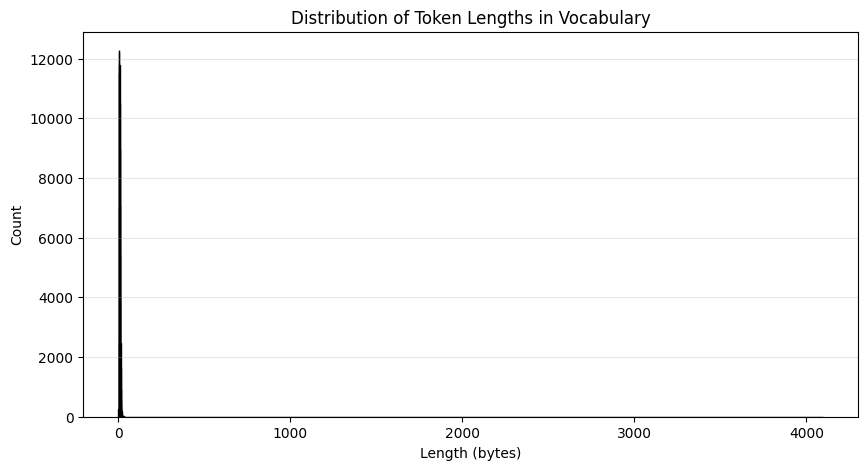

Top 20 Merged Tokens (in order of creation):
 1. ' t'
 2. ' a'
 3. 'he'
 4. 'in'
 5. 're'
 6. 'on'
 7. 'at'
 8. 'er'
 9. ' s'
10. ' the'
11. 'is'
12. ' c'
13. 'en'
14. 'it'
15. 'or'
16. 'al'
17. 'es'
18. ' w'
19. 'an'
20. 'ou'


In [21]:
# 1. Visualize Token Lengths
token_lengths = [len(t) if isinstance(t, bytes) else len(t.encode()) for t in vocab.keys()]

plt.figure(figsize=(10, 5))
plt.hist(token_lengths, bins=range(min(token_lengths), max(token_lengths) + 1), color='skyblue', edgecolor='black')
plt.title("Distribution of Token Lengths in Vocabulary")
plt.xlabel("Length (bytes)")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Visualize top 20 Merges
top_merges = rule_set[:20]
merge_labels = [pair_to_str(p) for p in top_merges]
# We'll need to re-extract frequencies if we want to plot the exact values at the time of merge, 
# but for now, let's just list the sequence of the first 20 tokens created.
print("Top 20 Merged Tokens (in order of creation):")
for i, label in enumerate(merge_labels):
    print(f"{i+1:2d}. {repr(label)}")


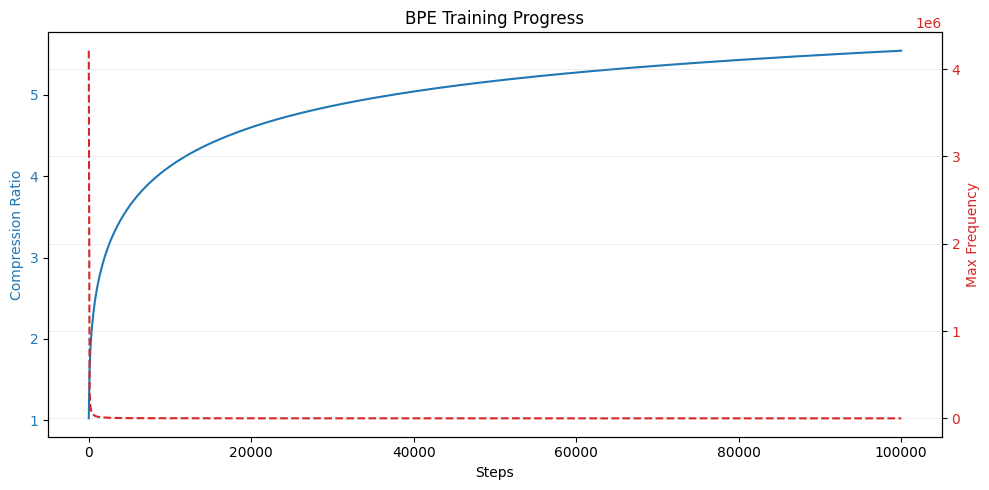

In [22]:
# 3. Visualize Training Metrics
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Steps')
ax1.set_ylabel('Compression Ratio', color=color)
ax1.plot(history["step"], history["compression_ratio"], color=color, label="Compression Ratio")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Max Frequency', color=color)
ax2.plot(history["step"], history["max_freq"], color=color, linestyle='--', label="Max Pair Frequency")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("BPE Training Progress")
fig.tight_layout()
plt.grid(alpha=0.2)
plt.show()


## Encoding and Decoding

Finally, let's see how our tokenizer handles a sample sentence.


In [23]:
def encode(text: str, vocab: dict, rule_set: list, special_tokens: list) -> list[int]:
    # This is a simplified educational encoder
    # In practice, this would use the rule_set to iteratively merge tokens
    tokens = pre_tokenize(text, special_tokens)
    
    # Split tokens into bytes/special strings
    current_tokens = []
    for t in tokens:
        if t in special_tokens:
            current_tokens.append(t)
        else:
            current_tokens.extend([bytes([b]) for b in t.encode("utf-8")])
            
    # Apply merges in order
    for pair in rule_set:
        first, second = pair
        new_token = first + second
        new_tokens = []
        i = 0
        while i < len(current_tokens):
            if i < len(current_tokens) - 1 and current_tokens[i] == first and current_tokens[i+1] == second:
                new_tokens.append(new_token)
                i += 2
            else:
                new_tokens.append(current_tokens[i])
                i += 1
        current_tokens = new_tokens
        
    return [vocab[t] for t in current_tokens]

def decode(ids: list[int], id_to_token: dict) -> str:
    parts = []
    for idx in ids:
        token = id_to_token[idx]
        if isinstance(token, bytes):
            parts.append(token)
        else:
            parts.append(token.encode("utf-8"))
    return b"".join(parts).decode("utf-8", errors="replace")

sample_text = "Hello, world! <think>Is this working?</think>"
encoded = encode(sample_text, vocab, rule_set, SPECIAL_TOKENS)
decoded = decode(encoded, id_to_token)

print(f"Sample Text: {sample_text}")
print(f"Encoded IDs: {encoded}")
print(f"Decoded Text: {decoded}")
print(f"Compression ratio: {len(sample_text) / len(encoded):.2f}x")

# Print table of token IDs and their corresponding tokens for the sample text
df_table = pd.DataFrame({
    "Token ID": encoded,
    "Token": [token_to_str(id_to_token[id]) for id in encoded]
})
print("\nToken ID to Token Mapping for Sample Text:")
df_table.T


Sample Text: Hello, world! <think>Is this working?</think>
Encoded IDs: [72, 38726, 1490, 33, 262, 5334, 479, 83639, 263]
Decoded Text: Hello, world!<think>Is this working?</think>
Compression ratio: 5.00x

Token ID to Token Mapping for Sample Text:


,0,1,2,3,4,5,6,7,8
Token ID,72,38726,1490,33,262,5334,479,83639,263
Token,H,"ello,",world,!,<think>,Is,this,working?,</think>


## Saving the Tokenizer

In this section, we will create a table that maps each token ID to its corresponding token string. This will help us understand how the tokenizer encodes text into token IDs and how it decodes them back into text.

In [33]:
tokenizer_df = pd.DataFrame({
    "Token ID": list(vocab.values()),
    "Token": [token_to_str(t) for t in vocab.keys()]
})
tokenizer_df.to_csv("tokenizer_vocabulary.csv", index=False)
tokenizer_df.to_json("tokenizer_vocabulary.jsonl", orient="records", lines=True)
tokenizer_df.to_json("tokenizer_vocabulary.json")
print("\nFull Tokenizer Vocabulary (Total {} tokens)".format(len(vocab)))
tokenizer_df.head(20)


Full Tokenizer Vocabulary (Total 100264 tokens)


,Token ID,Token
0,0, 
1,1,
2,2,
3,3,
4,4,
5,5,
6,6,
7,7,
8,8,
9,9,\t
